# Code for Generating Bifurcation Diagrams for Consumer-Resource Models

The parameters are labeled as they are in the supplemental information, $\Pi_1, \ldots, \Pi_8$.
 

In [10]:
### Preamble inclusions ###
using Plots
using DataFrames
using DynamicalSystems
using ProgressMeter
using DifferentialEquations
using DiffEqCallbacks
using Arrow

include("parameter_collection.jl");
include("utility_functions.jl");

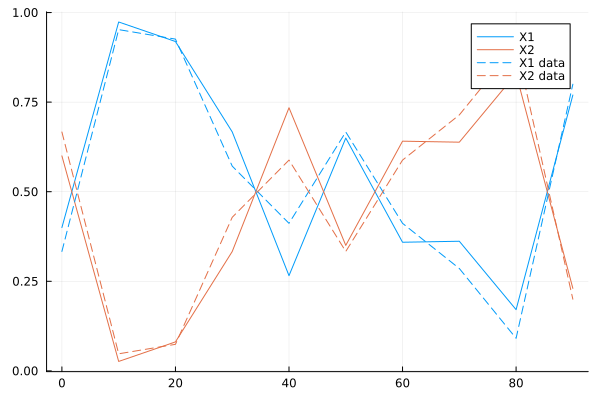

In [38]:
### Plot example system

ex_params = Pi_8;
ex_data = DataFrame(Arrow.Table("data/c_10d_rel.arrow"));
ex_times = Vector(ex_data.time);

example_sol = integrate_dilution_system(
    sys,
    ex_params,
    initial_values,
    (0, ex_times[end]),
    ex_times[2:end-1],
    dilution_affect_3(0.1, initial_values),
    maxiters = 1e10,
    reltol = 1e-16,
    abstol = 1e-8,
    progress = true
);

ex_vals = permutedims(reduce(hcat, get_dilution_values(ex_times, example_sol, lr = :right)))[:, 1:2];

plot(ex_times, ex_vals ./ sum(ex_vals, dims = 2), label = ["X1" "X2"], markerstrokewidth = 2, color = [1 2])
plot!(ex_times, Matrix(ex_data[:, 2:3]), label = ["X1 data" "X2 data"], linestyle = :dash, color = [1 2])

In [ ]:
### Choose System Parameters for bifurcation diagram ###
sys = cr_model_co1!;

tau = 10.0;

initial_values = ivs;
initial_params = Pi_1;
final_params = Pi_5;

interpolation_step_size = 0.05;
t_interpolation = collect(0.0:interpolation_step_size:1.0);
params_interpolation_list = [
    final_params.*t + (1.0 - t).*initial_params for t in t_interpolation
];


In [6]:
### generate orbit diagram data ###

orbit_length = 20;
N_orbit_start = 500;
dilution_times = collect(tau:tau:tau*(N_orbit_start + orbit_length - 1));

orbit_dimension = 2
orbit_values_matrix = zeros((length(params_interpolation_list), orbit_length));

pm = Progress(length(eachindex(params_interpolation_list)), "Calculating Orbits: ")
for i in eachindex(params_interpolation_list)
    solution_trajectory = integrate_dilution_system(
        sys,
        params_interpolation_list[i],
        initial_values,
        (0, dilution_times[end]),
        dilution_times,
        dilution_affect_3(0.1, initial_values),
        maxiters = 1e10,
        reltol = 1e-16,
        abstol = 1e-8,
        progress = true
    )
    orbit_values = permutedims(reduce(hcat, get_dilution_values(dilution_times, solution_trajectory, lr = :right)))
    orbit_values_matrix[i, :] = orbit_values[end-orbit_length+1:end, orbit_dimension]
    next!(pm)
end


Calculating Orbits: 100%|███████████████████████████████| Time: 0:00:16


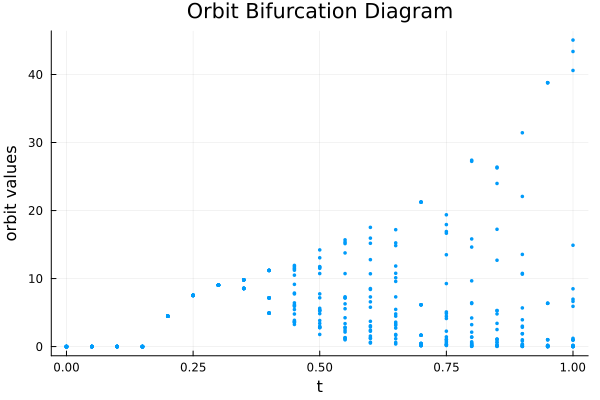

In [7]:
### create orbit bifurcation diagram ###

p1 = scatter(t_interpolation, orbit_values_matrix,
    color = 1,
    markersize = 2,
    markerstrokewidth = 0,
    label = "",
    title = "Orbit Bifurcation Diagram",
    xlabel = "t",
    ylabel = "orbit values"

)

In [8]:
### generate Lyapunov exponent data ###

lyp_spec_mat = zeros((length(params_interpolation_list), 4))
pm = Progress(length(params_interpolation_list), "Calculating Lyp Exp: ")
for i in eachindex(params_interpolation_list)
    ds = DeterministicIteratedMap(
        construct_chaostools_forward_map(cr_model_co1!, tau), 
        initial_values, 
        params_interpolation_list[i]
    )
    lyp_spec_mat[i, :] = lyapunovspectrum(ds, 1000, show_progress = false)
    next!(pm)
end


Calculating Lyp Exp: 100%|██████████████████████████████| Time: 0:00:49


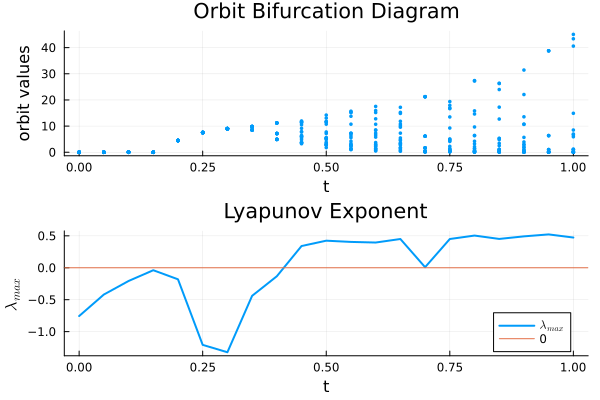

In [9]:
### plot largest Lyapunov exponent ###

p2 = plot(t_interpolation, lyp_spec_mat[:, 1],
    linewidth = 2,
    label = "\$\\lambda_{max}\$",
    xlabel = "t",
    ylabel = "\$\\lambda_{max}\$",
    title = "Lyapunov Exponent",
    legend = :bottomright

)
hline!(p2, [0.0], label = "0")
plot(p1, p2, layout = grid(2, 1))